In [13]:
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt


### 1 - Customers Data

In [25]:
customers=pd.read_excel("QbmrBZ/customers.xlsx")
customers

,CustomerID,CustomerName,Email,Gender,Age,GeographyID
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2
1,2,Sarah Brown,sarah.brown@example.com,Female,37,4
2,3,Robert Hernandez,robert.hernandez@example.com,Female,26,6
3,4,David Garcia,david.garcia@example.com,Male,25,8
4,5,Emma Miller,emma.miller@example.com,Female,41,4
...,...,...,...,...,...,...
95,96,Emily Gonzalez,emily.gonzalez@example.com,Female,38,10
96,97,Emily Rodriguez,emily.rodriguez@example.com,Female,51,3
97,98,Chris Lopez,chris.lopez@example.com,Female,55,10
98,99,Laura Hernandez,laura.hernandez@example.com,Male,41,5


In [15]:
customers.shape

(100, 6)

In [16]:
customers.head()

,CustomerID,CustomerName,Email,Gender,Age,GeographyID
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2
1,2,Sarah Brown,sarah.brown@example.com,Female,37,4
2,3,Robert Hernandez,robert.hernandez@example.com,Female,26,6
3,4,David Garcia,david.garcia@example.com,Male,25,8
4,5,Emma Miller,emma.miller@example.com,Female,41,4


In [26]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    100 non-null    int64 
 1   CustomerName  100 non-null    object
 2   Email         100 non-null    object
 3   Gender        100 non-null    object
 4   Age           100 non-null    int64 
 5   GeographyID   100 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [17]:
customers.isna().sum()

CustomerID      0
CustomerName    0
Email           0
Gender          0
Age             0
GeographyID     0
dtype: int64

In [18]:
customers.duplicated().sum()

np.int64(0)

In [19]:
customers.Gender.value_counts()

Gender
Female    54
Male      46
Name: count, dtype: int64

In [20]:
customers.Age.min(),customers.Age.max(),customers.Age.mean()

(18, 69, np.float64(41.99))

(array([ 8., 14., 10., 13., 13., 10.,  8.,  6., 10.,  8.]),
 array([18. , 23.1, 28.2, 33.3, 38.4, 43.5, 48.6, 53.7, 58.8, 63.9, 69. ]),
 <BarContainer object of 10 artists>)

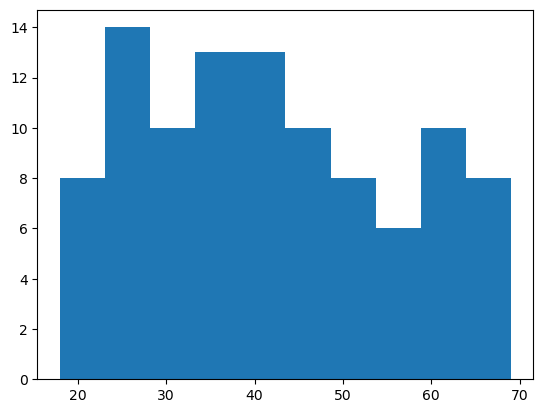

In [21]:
plt.hist(customers.Age)

In [22]:
customers.groupby("Gender")["Age"].mean()

Gender
Female    42.981481
Male      40.826087
Name: Age, dtype: float64

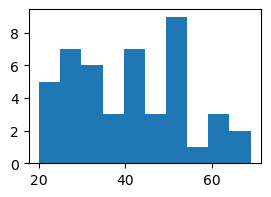

In [30]:
plt.figure(figsize=(3,2))
plt.hist(customers[customers.Gender=="Male"]["Age"])
plt.show()

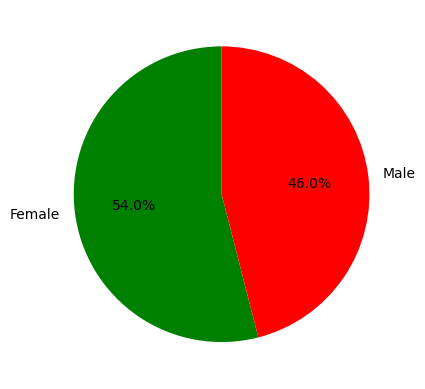

In [42]:
plt.pie(customers.Gender.value_counts(),labels=customers.Gender.value_counts().index,autopct="%1.1f%%",startangle=90,radius=1,colors=["green","red"])
plt.show()

In [43]:
customers["Age_Category"]=pd.cut(customers.Age,bins=[18,30,40,50,60,70],
                           labels=["18-30","31-40","41-50","51-60","61-70"])
Age_Freq=customers.Age_Category.value_counts()
Age_Freq

Age_Category
31-40    24
18-30    22
41-50    22
51-60    16
61-70    14
Name: count, dtype: int64

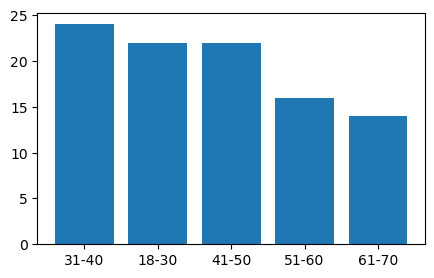

In [45]:
plt.figure(figsize=(5,3))
plt.bar(x=Age_Freq.index,height=Age_Freq.values)
plt.show()

### 2.Costomer's Data Geography

In [47]:
geography=pd.read_excel("QbmrBZ\geography.xlsx")

In [50]:
geography.head(3)

,ID,Region,City
0,1,UK,London
1,2,Germany,Berlin
2,3,France,Paris


In [51]:
customers_updated=pd.merge(customers,geography,how="left",left_on="CustomerID",right_on="ID").drop("ID",axis=1)

In [57]:
customers_updated.head(3)

,CustomerID,CustomerName,Email,Gender,Age,GeographyID,Age_Category,Region,City
0,1,Emma Anderson,emma.anderson@example.com,Male,50,2,41-50,UK,London
1,2,Sarah Brown,sarah.brown@example.com,Female,37,4,31-40,Germany,Berlin
2,3,Robert Hernandez,robert.hernandez@example.com,Female,26,6,18-30,France,Paris


### 3-Products Data